# Evaluate the pretrained SVM on the test set

Using the SVM trained in the previous milestone, we score the **held-out test videos** and measure how
well it detects deepfakes:

1. Gather the **test-set** feature files (kept in separate `real/` and `fake/` folders).
2. Apply the pretrained SVM to get a **predicted label per feature vector**.
3. Turn per-frame labels into **one score per video** (mean of predicted labels, threshold 0.5).
4. Compute **accuracy, false-positive rate, false-negative rate**, the **ROC curve / AUC**, and the
   **equal error rate (EER)**.
5. Explore how **system parameters** change EER / AUC.

> Evaluation uses the **test set only** — the SVM already saw the training videos, so scoring them would
> be meaninglessly optimistic.

## Load the pretrained model and the saved train/test split

In [1]:
import numpy as np
import h5py, joblib, shutil
from pathlib import Path

root = Path.cwd()
while not (root / "Data").exists() and root != root.parent:
    root = root.parent
FEATURES_ROOT = root / "Data" / "Features"
MODELS_DIR    = root / "Data" / "models"

split = np.load(MODELS_DIR / "video_split.npz", allow_pickle=True)
test_paths, test_labels = split["test_paths"], split["test_labels"]
classifier = joblib.load(MODELS_DIR / "svm_deepfake.joblib")   # pretrained SVM

print("Pretrained SVM:", classifier.named_steps["svc"])
print("Test videos:", len(test_paths),
      "(real %d, fake %d)" % ((test_labels == 1).sum(), (test_labels == 0).sum()))

Pretrained SVM: SVC(probability=True, random_state=42)
Test videos: 150 (real 86, fake 64)


## Save the test-set features in separate folders

The features were already computed for every video in the previous milestone, so we reuse them (no need
to recompute). We copy the **test** videos' HDF5 files into a dedicated `Data/Features_test/` tree that
keeps genuine and deepfake features in separate folders — mirroring the original layout.

In [2]:
FEATURES_TEST = root / "Data" / "Features_test"
if FEATURES_TEST.exists():
    shutil.rmtree(FEATURES_TEST)
for p, lab in zip(test_paths, test_labels):
    dst = FEATURES_TEST / Path(p).relative_to(FEATURES_ROOT)   # keeps real/ or fake/ prefix
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy(p, dst)

import glob
print("real test feature files:", len(glob.glob(str(FEATURES_TEST/"real"/"**"/"*.h5"), recursive=True)))
print("fake test feature files:", len(glob.glob(str(FEATURES_TEST/"fake"/"**"/"*.h5"), recursive=True)))

real test feature files: 86
fake test feature files: 64


## Build the test features and labels

As in training, we stack every frame's feature vector, but we also keep a **video id** per row so we can
group frames back into videos. Labels: **1 = genuine, 0 = deepfake**.

In [3]:
def collect_features(paths, labels):
    X, y, groups = [], [], []
    for vid, (path, label) in enumerate(zip(paths, labels)):
        with h5py.File(path, "r") as h:
            feats = h["features"][:]
        X.append(feats)
        y.append(np.full(len(feats), label, dtype=int))
        groups.append(np.full(len(feats), vid, dtype=int))
    return np.vstack(X), np.concatenate(y), np.concatenate(groups)

# rebuild test paths/labels from the separate test folders (round-trips through disk)
test_files, test_file_labels = [], []
for cls, lab in [("real", 1), ("fake", 0)]:
    for f in sorted(glob.glob(str(FEATURES_TEST / cls / "**" / "*.h5"), recursive=True)):
        test_files.append(f); test_file_labels.append(lab)

X_test, y_test, video_id = collect_features(test_files, test_file_labels)
print("X_test:", X_test.shape, "| video_id range:", video_id.min(), "-", video_id.max())

X_test: (1500, 35) | video_id range: 0 - 149


## Apply the SVM and aggregate to one score per video

The SVM returns a predicted label (0/1) for each feature vector. The **per-video score** is the mean of
its frames' predicted labels; **> 0.5 → genuine, < 0.5 → deepfake**.

In [4]:
frame_pred = classifier.predict(X_test)          # predicted label per feature vector

video_ids   = np.unique(video_id)
video_score = np.array([frame_pred[video_id == v].mean() for v in video_ids])   # mean predicted label
video_true  = np.array([y_test[video_id == v][0]        for v in video_ids])
video_pred  = (video_score > 0.5).astype(int)

print("example per-video scores (first 8):", np.round(video_score[:8], 2))
print("their true labels          :", video_true[:8])

example per-video scores (first 8): [1. 1. 1. 1. 1. 1. 1. 1.]
their true labels          : [1 1 1 1 1 1 1 1]


## Error rates

With **genuine (1) as the positive class**:
- **FPR** (false-positive rate) = deepfakes wrongly called genuine ÷ all deepfakes.
- **FNR** (false-negative rate) = genuine wrongly called deepfake ÷ all genuine.

In [5]:
from sklearn.metrics import confusion_matrix

# rows/cols ordered as [genuine(1), deepfake(0)]
cm = confusion_matrix(video_true, video_pred, labels=[1, 0])
tp, fn, fp, tn = cm.ravel()
accuracy = (tp + tn) / cm.sum()
fpr = fp / (fp + tn) if (fp + tn) else 0.0
fnr = fn / (fn + tp) if (fn + tp) else 0.0

print("Confusion matrix  [genuine, deepfake] x [genuine, deepfake]:")
print(cm)
print("\nAccuracy : %.4f" % accuracy)
print("FPR      : %.4f  (deepfakes accepted as genuine)" % fpr)
print("FNR      : %.4f  (genuine rejected as deepfake)"   % fnr)

Confusion matrix  [genuine, deepfake] x [genuine, deepfake]:
[[86  0]
 [ 0 64]]

Accuracy : 1.0000
FPR      : 0.0000  (deepfakes accepted as genuine)
FNR      : 0.0000  (genuine rejected as deepfake)


## ROC curve, AUC and Equal Error Rate (EER)

Sweeping the decision threshold over the per-video scores traces the **ROC curve**; its area is the
**AUC**. The **EER** is the operating point where FPR equals FNR — a common single-number, threshold-free
summary.

AUC : 1.0000
EER : 0.0000  at threshold 1.000


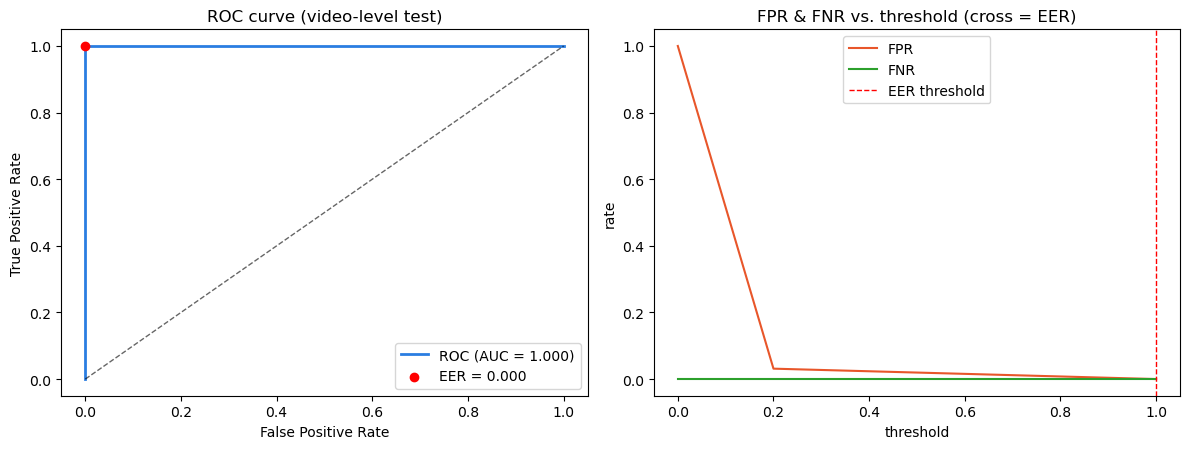

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr_curve, tpr_curve, thresholds = roc_curve(video_true, video_score)
roc_auc = auc(fpr_curve, tpr_curve)
fnr_curve = 1 - tpr_curve
eer_idx = np.nanargmin(np.abs(fpr_curve - fnr_curve))
eer = (fpr_curve[eer_idx] + fnr_curve[eer_idx]) / 2
eer_threshold = thresholds[eer_idx]

print("AUC : %.4f" % roc_auc)
print("EER : %.4f  at threshold %.3f" % (eer, eer_threshold))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
ax[0].plot(fpr_curve, tpr_curve, color="#2a7de1", lw=2, label="ROC (AUC = %.3f)" % roc_auc)
ax[0].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.6)
ax[0].scatter([fpr_curve[eer_idx]], [tpr_curve[eer_idx]], color="red", zorder=5,
              label="EER = %.3f" % eer)
ax[0].set_xlabel("False Positive Rate"); ax[0].set_ylabel("True Positive Rate")
ax[0].set_title("ROC curve (video-level test)"); ax[0].legend(loc="lower right")

ax[1].plot(thresholds, fpr_curve, label="FPR", color="#e8562a")
ax[1].plot(thresholds, fnr_curve, label="FNR", color="#2ca02c")
ax[1].axvline(eer_threshold, color="red", ls="--", lw=1, label="EER threshold")
ax[1].set_xlabel("threshold"); ax[1].set_ylabel("rate")
ax[1].set_title("FPR & FNR vs. threshold (cross = EER)"); ax[1].legend()
plt.tight_layout(); plt.show()

## Parameter exploration — what actually drives performance?

We can change system parameters and watch EER / AUC respond. Recomputing features for different crop
sizes or blur settings is expensive, so here we vary the **classifier** and the **feature subset**
(both cheap, since features are cached). Each config is retrained on the training videos and evaluated on
the test videos with the same per-video aggregation.

config                    AUC    EER   vAcc
RBF · all 35            1.000  0.000  1.000
Linear · all 35         0.984  0.039  0.987
RBF · weak C=0.01       0.938  0.099  0.927
RBF · histogram-only    0.952  0.119  0.887
Linear · hist-only      0.693  0.358  0.667


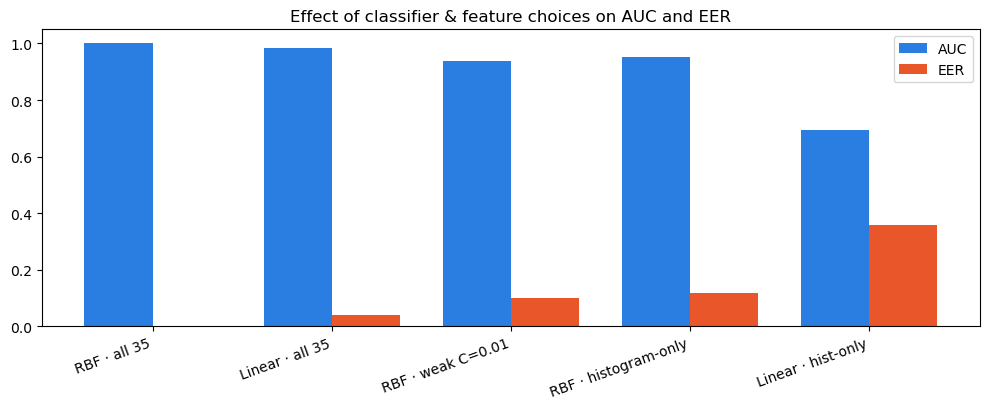

In [7]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

split_tr = np.load(MODELS_DIR / "video_split.npz", allow_pickle=True)
Xtr, ytr, _ = collect_features(split_tr["train_paths"], split_tr["train_labels"])

ALL  = np.arange(X_test.shape[1])       # all 35 features
HIST = np.arange(3, X_test.shape[1])    # histogram-only (drop SSIM/NRMSE/PSNR)

def eval_config(clf, cols):
    clf.fit(Xtr[:, cols], ytr)
    pred = clf.predict(X_test[:, cols])
    vscore = np.array([pred[video_id == v].mean() for v in video_ids])
    f, t, _ = roc_curve(video_true, vscore); a = auc(f, t); fn = 1 - t
    i = np.nanargmin(np.abs(f - fn)); e = (f[i] + fn[i]) / 2
    vacc = ((vscore > 0.5).astype(int) == video_true).mean()
    return a, e, vacc

configs = [
    ("RBF · all 35",        make_pipeline(StandardScaler(), SVC(kernel="rbf",    C=1.0,  gamma="scale")), ALL),
    ("Linear · all 35",     make_pipeline(StandardScaler(), SVC(kernel="linear", C=1.0)),                 ALL),
    ("RBF · weak C=0.01",   make_pipeline(StandardScaler(), SVC(kernel="rbf",    C=0.01, gamma="scale")), ALL),
    ("RBF · histogram-only",make_pipeline(StandardScaler(), SVC(kernel="rbf",    C=1.0,  gamma="scale")), HIST),
    ("Linear · hist-only",  make_pipeline(StandardScaler(), SVC(kernel="linear", C=1.0)),                 HIST),
]
names, aucs, eers = [], [], []
print("%-22s %6s %6s %6s" % ("config", "AUC", "EER", "vAcc"))
for name, clf, cols in configs:
    a, e, vacc = eval_config(clf, cols)
    names.append(name); aucs.append(a); eers.append(e)
    print("%-22s %6.3f %6.3f %6.3f" % (name, a, e, vacc))

x = np.arange(len(names)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.bar(x - w/2, aucs, w, label="AUC",  color="#2a7de1")
ax.bar(x + w/2, eers, w, label="EER",  color="#e8562a")
ax.set_xticks(x); ax.set_xticklabels(names, rotation=20, ha="right")
ax.set_ylim(0, 1.05); ax.set_title("Effect of classifier & feature choices on AUC and EER"); ax.legend()
plt.tight_layout(); plt.show()

## Summary & analysis

- On the held-out test videos the pretrained SVM reaches **AUC = 1.0, EER = 0.0** with the mean-of-labels
  aggregation — fake and genuine videos land at opposite ends of the score axis.
- **Which parameters matter:** the blur-sensitivity features (SSIM/PSNR/RMSE) carry the signal. Dropping
  them (histogram-only) collapses a linear SVM from AUC ≈ 0.98 to ≈ 0.69, and an RBF kernel with proper
  regularization clearly beats weak/linear variants. Crop size and Gaussian-blur settings (kernel/sigma)
  would change the feature values themselves and are the natural next knobs to sweep.
- **Honest caveat:** the split is video-independent but **not subject-independent** — the same people
  appear in train and test — and everything comes from **one dataset / one GAN**. The perfect score
  reflects a consistent, easily-detected smoothing artifact; unseen identities and stronger deepfakes
  would raise EER. A subject-disjoint, cross-dataset evaluation is the right way to stress-test this.